In [ ]:
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [2]:
# loading the data
try:
    df = pd.read_csv('/kaggle/input/ibm-hr-analytics-attrition-dataset/WA_Fn-UseC_-HR-Employee-Attrition.csv')
    print('keggel')
except FileNotFoundError:
    df = pd.read_csv('HR-Employee-Attrition.csv')
    print('local')
df.head()

local


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [3]:
# Basic Checks
print(f'shape : {df.shape}\n')
print(f'shape : \n{df.isnull().sum()}\n')
print(f'duplicated : {df.duplicated().sum()}\n')
print({df.info()})

shape : (1470, 35)

shape : 
Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurr

In [4]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0


In [5]:
df.describe(include=['O']).transpose()

,count,unique,top,freq
Attrition,1470,2,No,1233
BusinessTravel,1470,3,Travel_Rarely,1043
Department,1470,3,Research & Development,961
EducationField,1470,6,Life Sciences,606
Gender,1470,2,Male,882
JobRole,1470,9,Sales Executive,326
MaritalStatus,1470,3,Married,673
Over18,1470,1,Y,1470
OverTime,1470,2,No,1054


### Exploratory Data Analysis

In [6]:
from ydata_profiling import ProfileReport

profile = ProfileReport(df, title="EDA Report")
profile.to_file("eda_report.html")
print('completed')

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


%|          | 0/35 [00:00<?, ?it/s]
%|█▍        | 5/35 [00:00<00:00, 46.29it/s]
100%|██████████| 35/35 [00:00<00:00, 94.38it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

completed


### Insights
#### Arittion columns states that our data is imbalanced.

In [7]:
# catagorical columns
data1 = df[['Attrition', 'BusinessTravel', 'Department', 'EducationField',
              'Gender', 'JobRole', 'MaritalStatus', 'OverTime']]
data1.head()

,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,OverTime
0,Yes,Travel_Rarely,Sales,Life Sciences,Female,Sales Executive,Single,Yes
1,No,Travel_Frequently,Research & Development,Life Sciences,Male,Research Scientist,Married,No
2,Yes,Travel_Rarely,Research & Development,Other,Male,Laboratory Technician,Single,Yes
3,No,Travel_Frequently,Research & Development,Life Sciences,Female,Research Scientist,Married,Yes
4,No,Travel_Rarely,Research & Development,Medical,Male,Laboratory Technician,Married,No


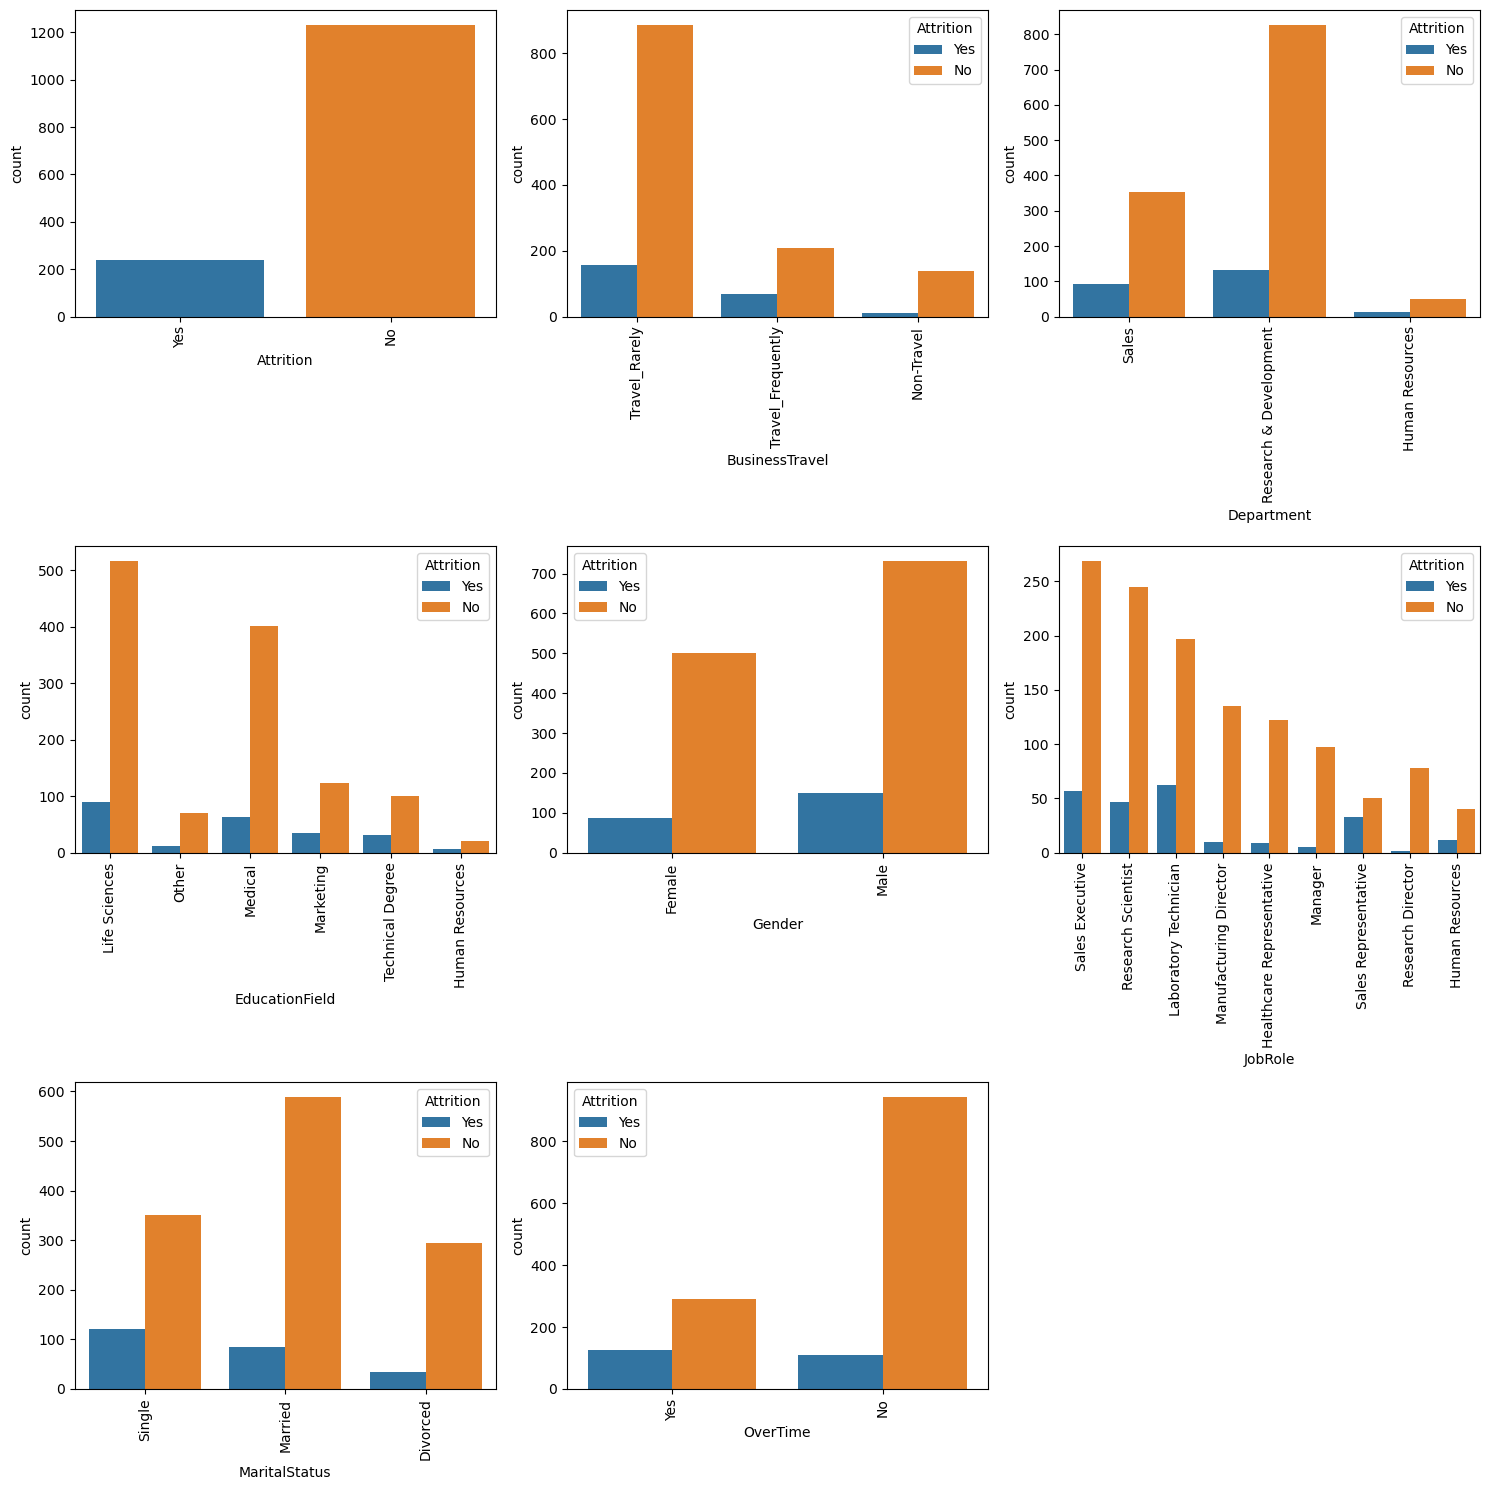

In [8]:
n = 1
plt.figure(figsize=(15, 15))
for i in data1.columns:
    if n <= len(data1.columns):
        ax = plt.subplot(3, 3, n)
        sns.countplot(data=data1, x=i, hue='Attrition')
        plt.xticks(rotation=90)
    n += 1
plt.tight_layout()
plt.show()

### Insights
#### Attrition Distribution : The majority of employees stay with the company, but a significant minority leave. This class imbalance should be considered during model training and evaluation.
#### BusinessTravel vs Attrition : Employees who travel frequently show higher attrition compared to those who travel rarely or not at all. Increased travel appears to contribute to burnout and higher turnover.
#### Department vs Attrition : The Sales department experiences higher attrition compared to Research & Development and Human Resources, indicating higher pressure or lower satisfaction in sales roles.
#### EducationField vs Attrition : Employees from Life Sciences and Medical backgrounds show relatively higher attrition in absolute numbers, while those from Technical Degree and Other fields also exhibit notable attrition, suggesting education background may influence retention patterns.
#### Gender vs Attrition : Attrition is observed in both genders, with males showing slightly higher attrition counts. However, the difference is not extreme, indicating gender alone is not a strong determinant of attrition.
#### JobRole vs Attrition : Sales Executives and Laboratory Technicians show higher attrition counts compared to other roles. Sales Representatives also exhibit relatively high turnover, highlighting role-specific stress and job nature as key factors.
#### MaritalStatus vs Attrition : Single employees show higher attrition compared to married and divorced employees. This suggests unmarried employees may have higher mobility and are more likely to switch jobs.
#### OverTime vs Attrition : Employees who work overtime have significantly higher attrition compared to those who do not. Overtime appears to be one of the strongest indicators of employee turnover.

In [9]:
data2 = df[['Education', 'EnvironmentSatisfaction', 'JobInvolvement', 'JobLevel',
     'JobSatisfaction', 'NumCompaniesWorked', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel',
            'TrainingTimesLastYear', 'WorkLifeBalance']]

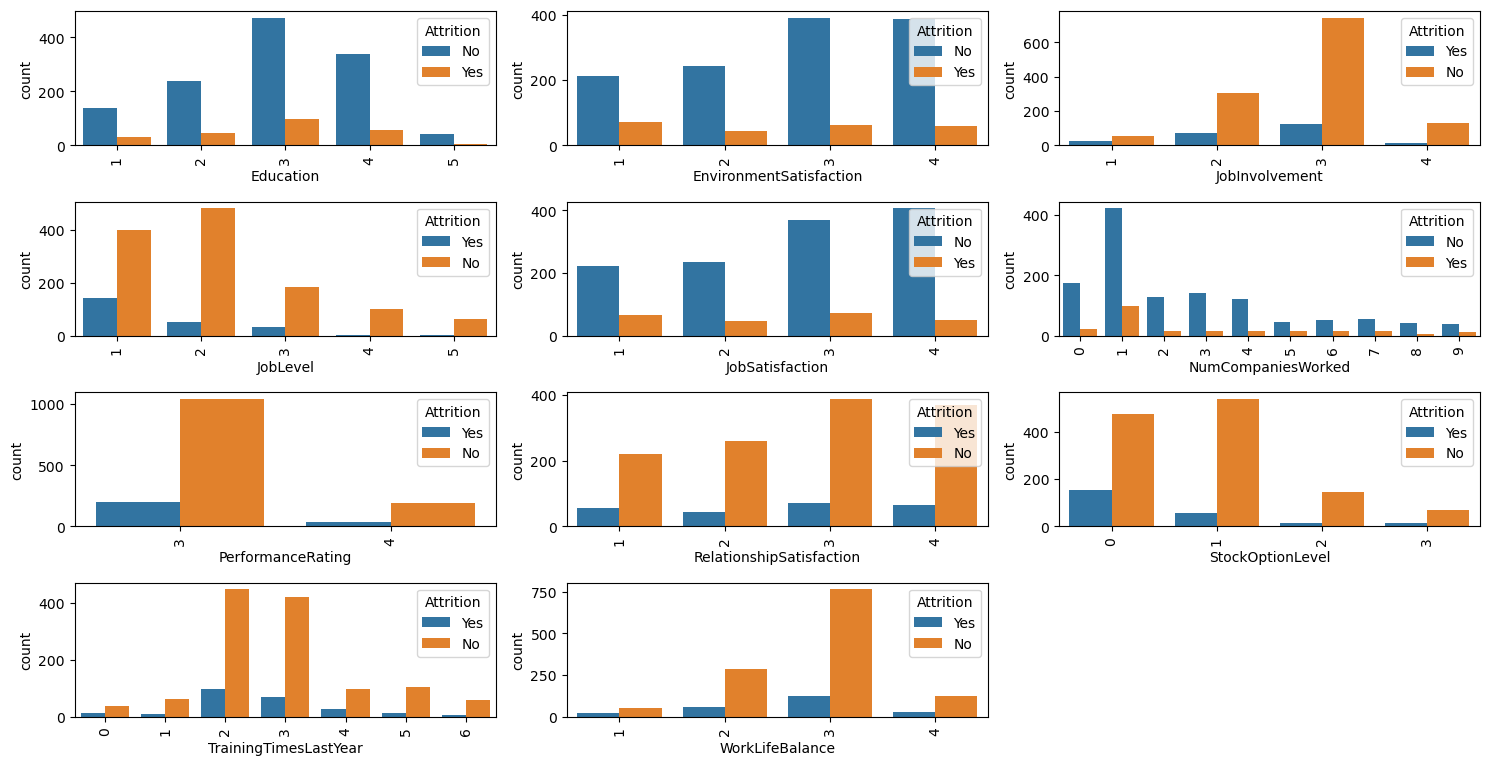

In [10]:
n = 1
plt.figure(figsize=(15, 15))
for i in data2.columns:
    if n <= len(data2.columns):
        ax = plt.subplot(8, 3, n)
        sns.countplot(data=data2, x=i, hue=df['Attrition'])
        plt.xticks(rotation=90)
    n += 1
plt.tight_layout()
plt.show()

### Insights
#### Employees with low Job Involvement (1–2) show significantly higher attrition compared to those with high involvement.
#### Employees at lower Job Levels (Level 1–2) are leaving the company more than senior-level employees.
#### Employees with low Job Satisfaction (1–2) have a much higher likelihood of attrition than satisfied employees.
#### Employees who have worked in fewer companies (0–2 previous companies) show higher attrition, indicating early-career instability.
#### Employees with lower Relationship Satisfaction (1–2) tend to leave more compared to those with better workplace relationships.
#### Employees with no or low Stock Options (0–1) have higher attrition than those with higher stock option levels.
#### Employees with poor Work-Life Balance (1–2) are more likely to leave compared to those with better balance.
#### Employees with lower Environment Satisfaction (1–2) show higher attrition than those satisfied with their work environment.

In [11]:
data3 = df[['Age',
              'DailyRate',
              'DistanceFromHome',
              'HourlyRate',
              'MonthlyIncome',
              'MonthlyRate',
              'PercentSalaryHike',
              'TotalWorkingYears',
              'YearsAtCompany',
              'YearsInCurrentRole',
              'YearsSinceLastPromotion',
              'YearsWithCurrManager']]

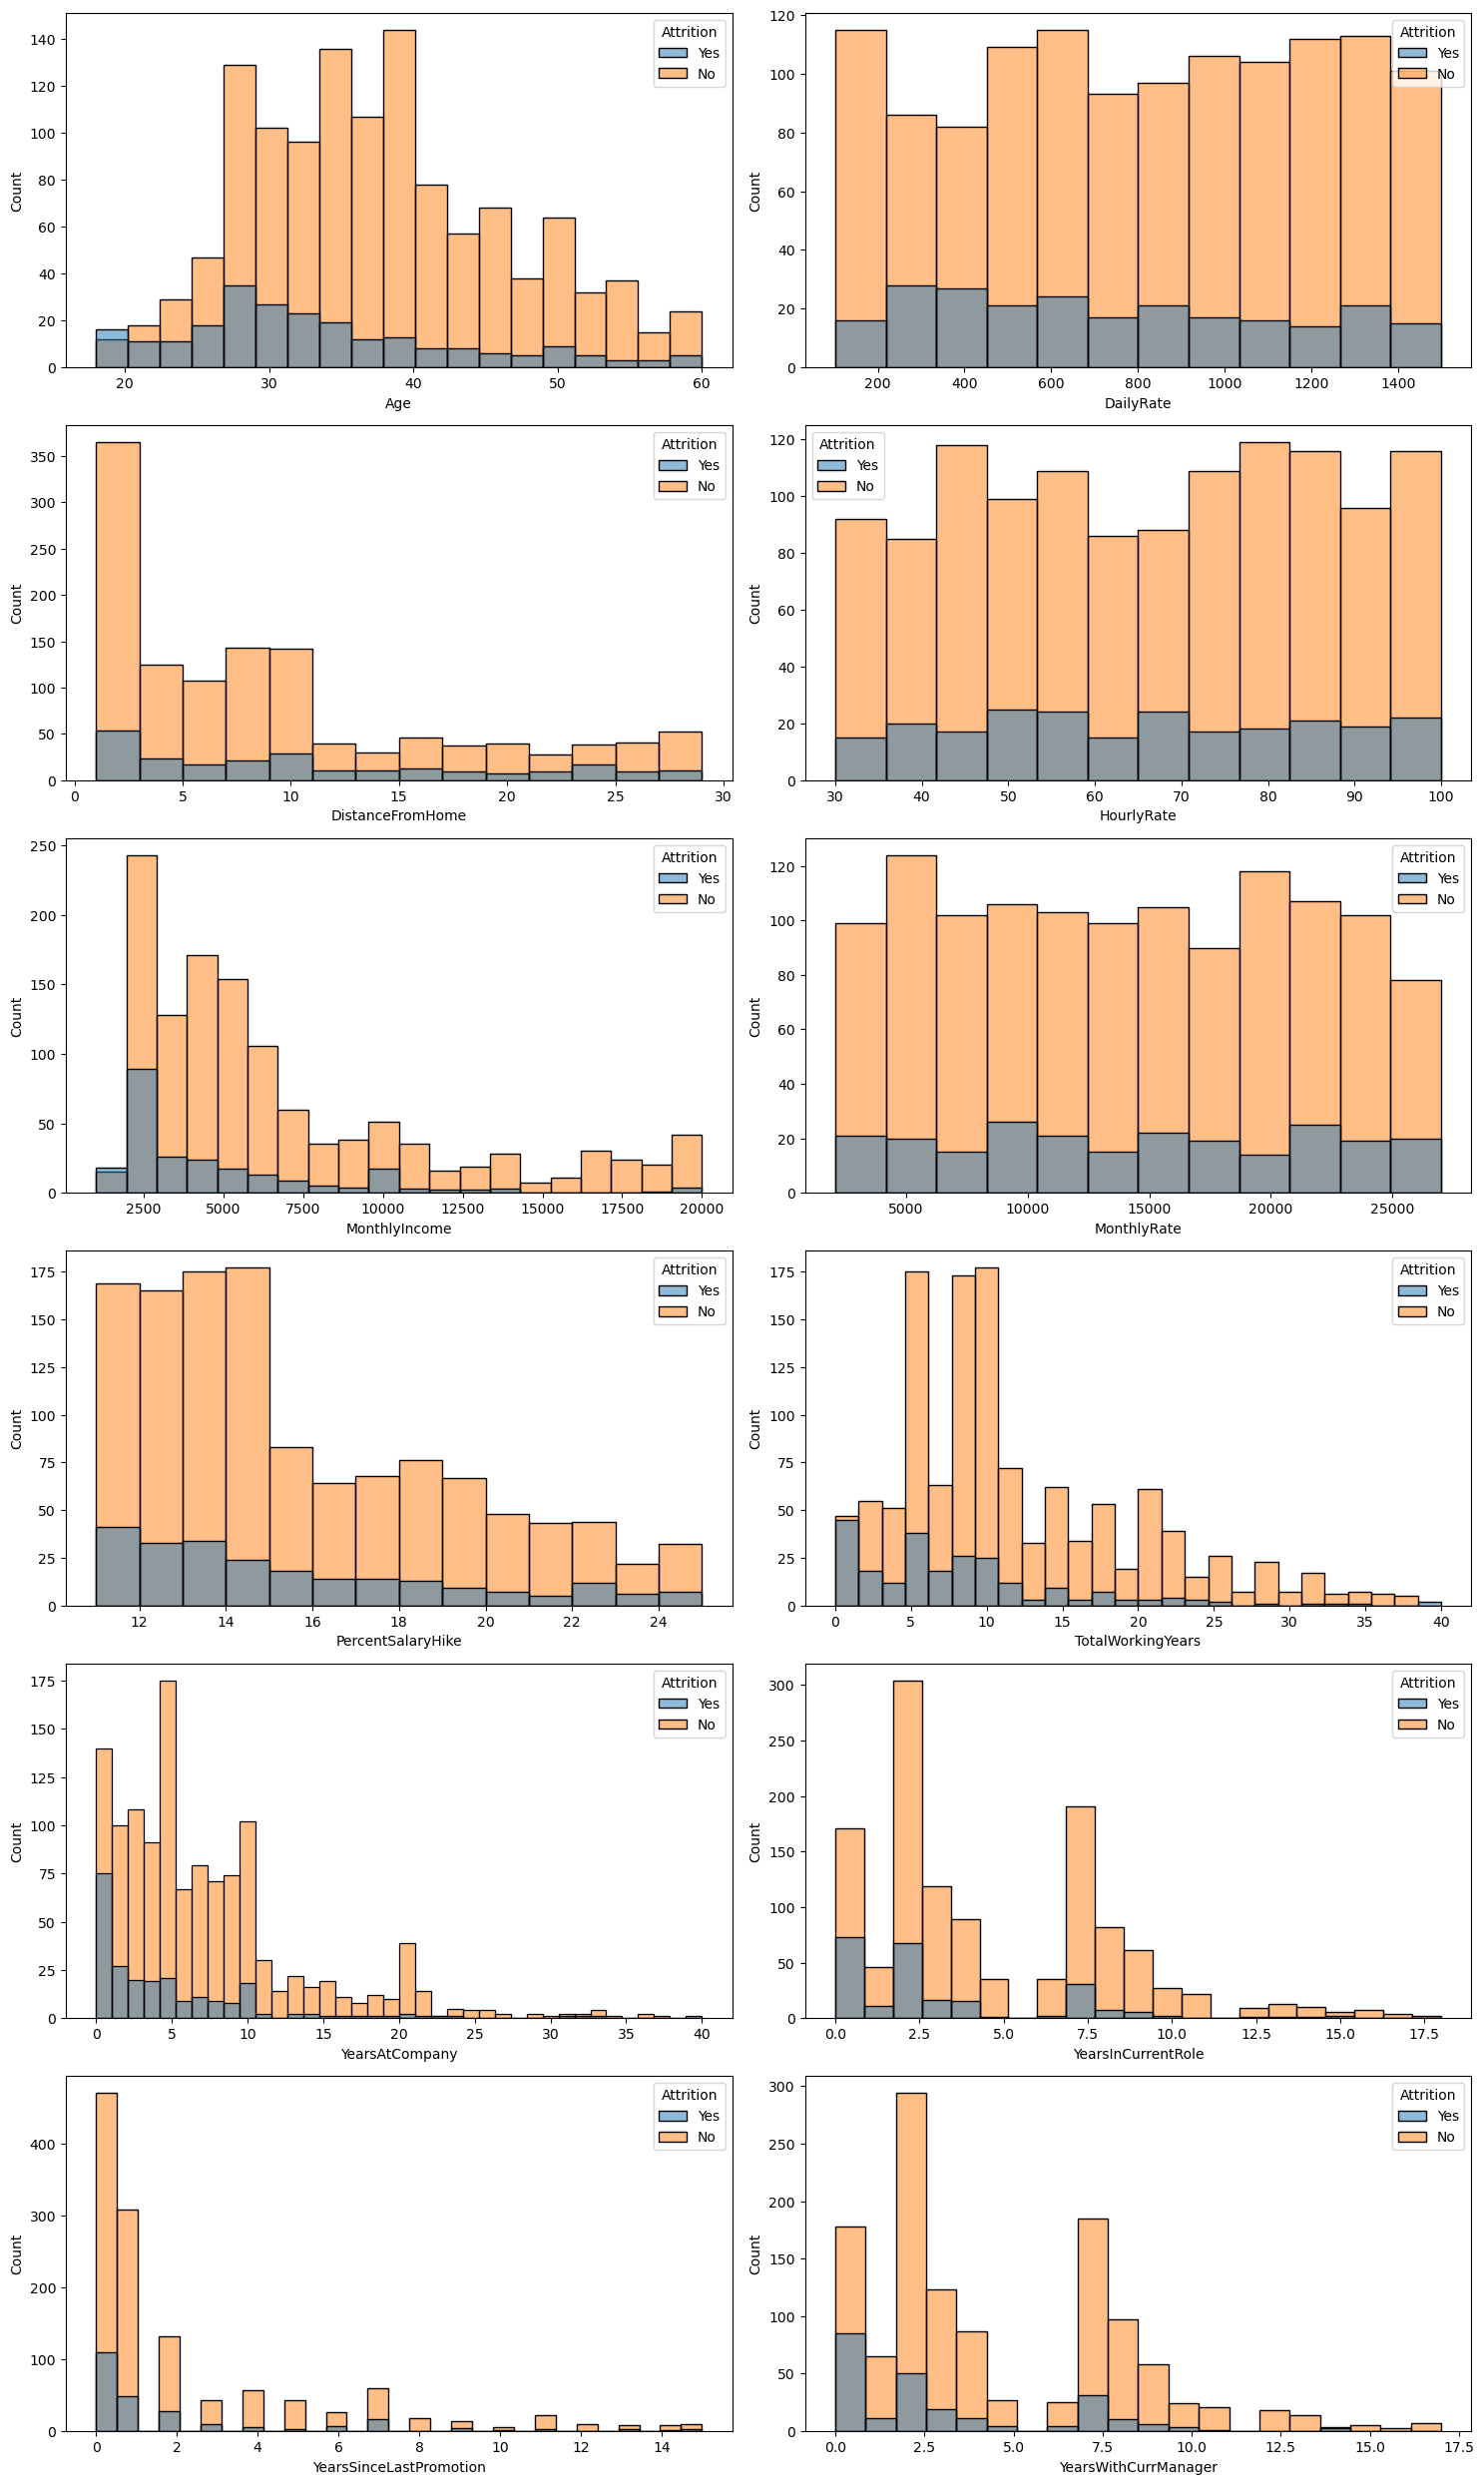

In [12]:
n = 1
plt.figure(figsize=(15, 25))
for i in data3.columns:
    if n <= len(data3.columns):
        ax = plt.subplot(6, 2, n)
        sns.histplot(x=data3[i], hue=df['Attrition'])
    n += 1
plt.tight_layout()
plt.show()

In [13]:
### label encodings
for i in df.columns:
    print(f' {i} : {df[i].unique()}')

 Age : [41 49 37 33 27 32 59 30 38 36 35 29 31 34 28 22 53 24 21 42 44 46 39 43
 50 26 48 55 45 56 23 51 40 54 58 20 25 19 57 52 47 18 60]
 Attrition : ['Yes' 'No']
 BusinessTravel : ['Travel_Rarely' 'Travel_Frequently' 'Non-Travel']
 DailyRate : [1102  279 1373 1392  591 1005 1324 1358  216 1299  809  153  670 1346
  103 1389  334 1123 1219  371  673 1218  419  391  699 1282 1125  691
  477  705  924 1459  125  895  813 1273  869  890  852 1141  464 1240
 1357  994  721 1360 1065  408 1211 1229  626 1434 1488 1097 1443  515
  853 1142  655 1115  427  653  989 1435 1223  836 1195 1339  664  318
 1225 1328 1082  548  132  746  776  193  397  945 1214  111  573 1153
 1400  541  432  288  669  530  632 1334  638 1093 1217 1353  120  682
  489  807  827  871  665 1040 1420  240 1280  534 1456  658  142 1127
 1031 1189 1354 1467  922  394 1312  750  441  684  249  841  147  528
  594  470  957  542  802 1355 1150 1329  959 1033 1316  364  438  689
  201 1427  857  933 1181 1395  662 1436  1

In [14]:
df['Attrition'] = df['Attrition'].map({'Yes' : 1, "No" : 0})

In [15]:
df['BusinessTravel'] = df['BusinessTravel'].map({'Travel_Rarely' : 1, 'Travel_Frequently' : 2, 'Non-Travel': 0})

In [16]:
df['Department'] = df['Department'].map({'Sales' : 0, 'Research & Development' : 2, 'Human Resources': 1})

In [17]:
df['EducationField'] = df['EducationField'].map({'Life Sciences' : 5, 'Other': 0, 'Medical': 4, 'Marketing' : 2, 'Technical Degree' : 3,
                                                 'Human Resources' : 1})

In [18]:
df['Gender'] = df['Gender'].map({'Female' : 0, 'Male' : 1})

In [19]:
df['JobRole'] = df['JobRole'].map({'Sales Executive' : 5, 'Research Scientist' : 6, 'Laboratory Technician' : 2,
                                  'Manufacturing Director' : 3, 'Healthcare Representative' : 2, 'Manager' : 1,
                                  'Sales Representative' : 4, 'Research Director' : 7, 'Human Resources' : 0})

In [20]:
df['MaritalStatus'] = df['MaritalStatus'].map({'Single' : 0, 'Married' : 1, 'Divorced' : 2})

In [21]:
df['OverTime'] = df['OverTime'].map({'Yes' : 1, 'No' : 0})

In [22]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
Attrition,1470.0,0.161224,0.367863,0.0,0.00,0.0,0.00,1.0
BusinessTravel,1470.0,1.086395,0.532170,0.0,1.00,1.0,1.00,2.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
Department,1470.0,1.350340,0.913768,0.0,0.00,2.0,2.00,2.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EducationField,1470.0,3.827891,1.401511,0.0,3.00,4.0,5.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0


In [23]:
# feature selection and droping unnecessary columns
df = df.drop(columns=['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours'])

In [24]:
data3.corr()

,Age,DailyRate,DistanceFromHome,HourlyRate,MonthlyIncome,MonthlyRate,PercentSalaryHike,TotalWorkingYears,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
Age,1.000000,0.010661,-0.001686,0.024287,0.497855,0.028051,0.003634,0.680381,0.311309,0.212901,0.216513,0.202089
DailyRate,0.010661,1.000000,-0.004985,0.023381,0.007707,-0.032182,0.022704,0.014515,-0.034055,0.009932,-0.033229,-0.026363
DistanceFromHome,-0.001686,-0.004985,1.000000,0.031131,-0.017014,0.027473,0.040235,0.004628,0.009508,0.018845,0.010029,0.014406
HourlyRate,0.024287,0.023381,0.031131,1.000000,-0.015794,-0.015297,-0.009062,-0.002334,-0.019582,-0.024106,-0.026716,-0.020123
MonthlyIncome,0.497855,0.007707,-0.017014,-0.015794,1.000000,0.034814,-0.027269,0.772893,0.514285,0.363818,0.344978,0.344079
MonthlyRate,0.028051,-0.032182,0.027473,-0.015297,0.034814,1.000000,-0.006429,0.026442,-0.023655,-0.012815,0.001567,-0.036746
PercentSalaryHike,0.003634,0.022704,0.040235,-0.009062,-0.027269,-0.006429,1.000000,-0.020608,-0.035991,-0.001520,-0.022154,-0.011985
TotalWorkingYears,0.680381,0.014515,0.004628,-0.002334,0.772893,0.026442,-0.020608,1.000000,0.628133,0.460365,0.404858,0.459188
YearsAtCompany,0.311309,-0.034055,0.009508,-0.019582,0.514285,-0.023655,-0.035991,0.628133,1.000000,0.758754,0.618409,0.769212
YearsInCurrentRole,0.212901,0.009932,0.018845,-0.024106,0.363818,-0.012815,-0.001520,0.460365,0.758754,1.000000,0.548056,0.714365


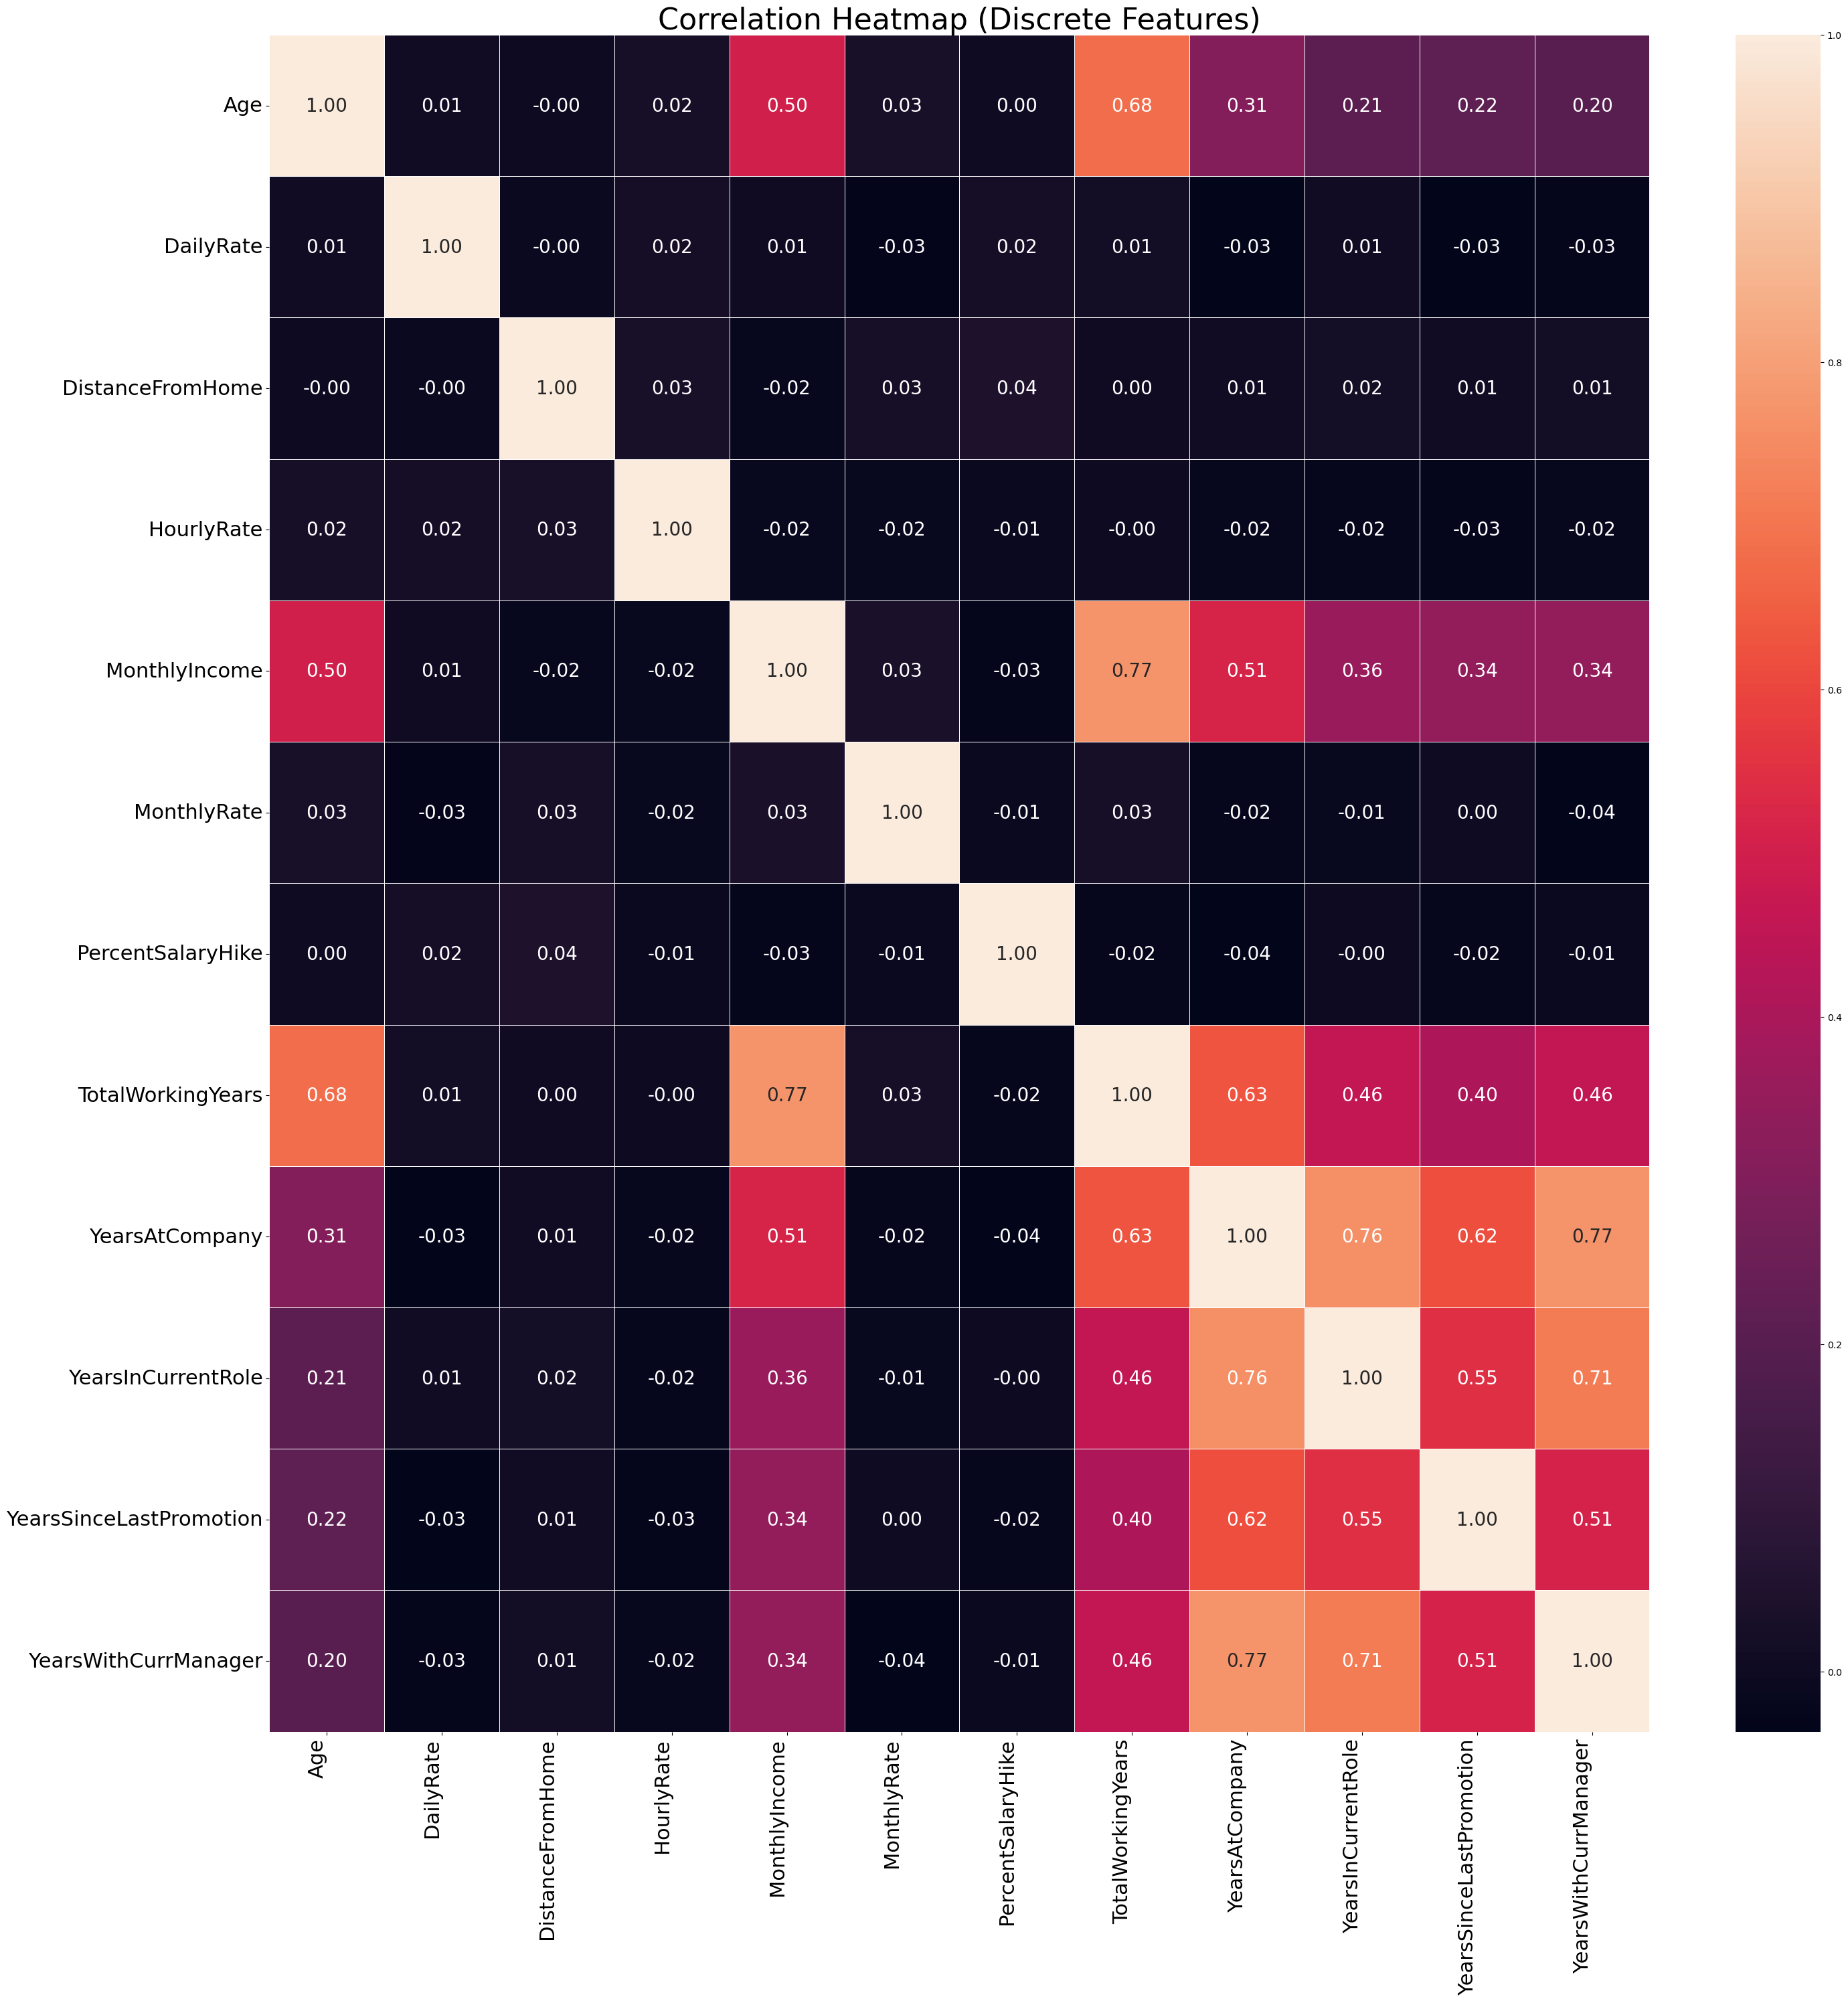

In [25]:
plt.figure(figsize=(30, 30))
sns.heatmap(data= data3.corr(), annot=True, fmt=".2f", linewidths=0.5, annot_kws={"size": 20})
plt.title("Correlation Heatmap (Discrete Features)", fontsize=32)
plt.xticks(rotation=90, ha="right", fontsize=22)
plt.yticks(rotation=0, ha="right", fontsize=22)

plt.tight_layout()
plt.show()

### Model

In [41]:
x = df.drop(columns='Attrition')
y = df['Attrition']

In [48]:
# Train test split
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

In [50]:
# Balcancing The Data
from collections import Counter
from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state=42)
print(Counter(y_train))
x_sm, y_sm = sm.fit_resample(x_train, y_train)
print(Counter(y_sm))

Counter({0: 986, 1: 190})
Counter({0: 986, 1: 986})


In [54]:
# Model Creation
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(criterion='entropy', max_depth=10, min_samples_leaf=1, min_samples_split=3, splitter='random', random_state=42)
dt.fit(x_sm, y_sm)

DecisionTreeClassifier(criterion='entropy', max_depth=10, min_samples_split=3,
                       random_state=42, splitter='random')

In [55]:
# Prediction
y_pred = dt.predict(x_test)

In [56]:
# model Evaluation
from sklearn.metrics import accuracy_score, classification_report, f1_score
print(f'Accuracy of the model is : {accuracy_score(y_test, y_pred)}\n')
print(f'f1 score of the model is : {f1_score(y_test, y_pred)}\n')
print(f'classification report of the model is : \n{classification_report(y_test, y_pred)}')


Accuracy of the model is : 0.7619047619047619

f1 score of the model is : 0.39655172413793105

classification report of the model is : 
              precision    recall  f1-score   support

           0       0.89      0.81      0.85       247
           1       0.33      0.49      0.40        47

    accuracy                           0.76       294
   macro avg       0.61      0.65      0.62       294
weighted avg       0.80      0.76      0.78       294



### Conclusion
#### he Decision Tree model achieved moderate performance on the employee attrition dataset, with an overall accuracy of ~76% and improved recall for the minority attrition class after applying SMOTE. While the model is able to identify a portion of employees likely to leave, there is still room for improvement in precision and overall predictive power. Future work will focus on experimenting with ensemble models, feature engineering, and hyperparameter tuning to achieve better and more reliable results.